# Tutorial to compute transport with WannierBerri for tight-binding models generated via Tailwater

In [1]:
#Define API Keys:
#Materials Project API Key
API_KEY =#Your Materials Project API Key
#Tailwater User + Password
TW_USER=# Your Tailwater Username
TW_PASS=#Your Tailwater Password

In [2]:
import os
from mp_api.client import MPRester
mp_id='mp-104' #Materials Project ID for Sb
with MPRester(API_KEY) as mpr:
    print(f"Querying the Materials Project for {mp_id}...")


    # 1. Fetch summary data (Structure and Band Gap)
    # Passing the ID in a list to material_ids isolates the specific material
    summary_docs = mpr.materials.summary.search(
        material_ids=[mp_id],
        fields=["material_id", "structure", "band_gap","dos"]
    )

    if not summary_docs:
        print(f"Could not find summary data for {mp_id}. Check the ID.")
        #return

    doc = summary_docs[0]
    band_gap = doc.band_gap
    structure = doc.structure
structure

/opt/anaconda3/envs/tailwater-test/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/anaconda3/envs/tailwater-test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Querying the Materials Project for mp-104...


Retrieving SummaryDoc documents: 100%|██████████| 1/1 [00:00<00:00, 7049.25it/s]


Structure Summary
Lattice
    abc : 4.581209043685215 4.581210190248658 4.581208787331966
 angles : 56.7469248798343 56.746923922373426 56.746918415943504
 volume : 62.881010949113254
      A : 3.83577146 0.0059445900000000005 2.50485494
      B : 1.35894867 3.58698298 2.5048549700000002
      C : 0.0085938 0.0059445800000000005 4.58119687
    pbc : True True True
PeriodicSite: Sb (1.396, 0.9654, 2.573) [0.2683, 0.2683, 0.2683]
PeriodicSite: Sb (3.807, 2.633, 7.018) [0.7317, 0.7317, 0.7317]

In [7]:
#Load Tailwater frontend
import numpy as np
from tailwater import (
    tw_api_call, compute_band_edges, align_to_vbm, tb_model,
    BulkDOS,
    SurfaceSpectralDensity,
    SurfaceGreensFunction,
    FermiArcMap, bulk_band_structure
)
import pybinding as pb
import matplotlib.pyplot as plt

In [8]:
paths = tw_api_call(structure, TW_USER, TW_PASS, "./outputs", "my_mat")

In [9]:
# Load the HDF5 the API produced — returns a tbmodels.Model with .to_pb()
model = tb_model.load("outputs/wannier90_hr.hdf5")
#Option to align VBM to zero energy for non-metals following Mat. Proj. convention
#model     = align_to_vbm(model)

[bands] path total length = 4.1096  -> N_path = 206 samples (spacing = 0.02)


Band structure: 100%|███████████████████████| 206/206 [00:00<00:00, 5552.26it/s]


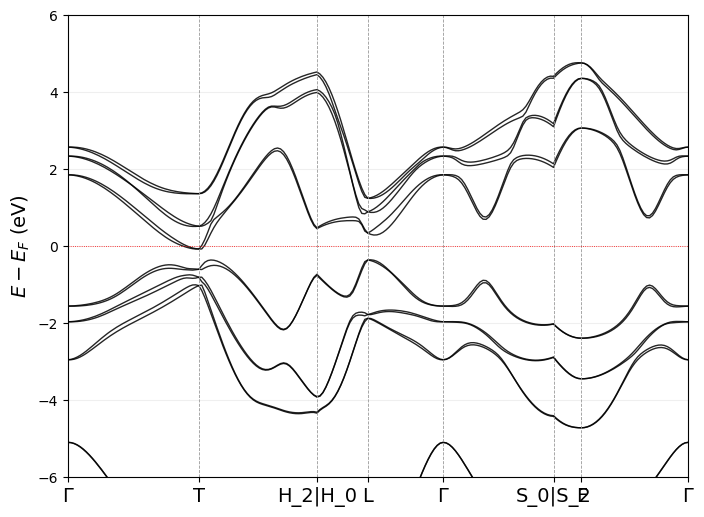

In [10]:
#Plot band structure using SeeKPath
fig = bulk_band_structure(model, auto=True, structure=structure,
                          spacing=0.02, e_range=(-6, 6))
fig

# Now that we have the model lets begin with computing DOS, Ohmic Conductivity and AHC

Loading hr-model ...
Building wannierberri System ...
Reading the system from TBmodels model. Needed data: {'Ham', 'AA'}
[16]
[17]
[23]
[25]
[29]
[31]
[18]
[22]
[32]
[20]
[27]
[19]
[21]
[24]
[26]
[28]
[30]
shape of Ham_R = (33, 36, 36)
Real-space lattice:
 [[3.83577146 0.00594459 2.50485494]
 [1.35894867 3.58698298 2.50485497]
 [0.0085938  0.00594458 4.58119687]]
Number of wannier functions: 36
Number of R points: 33
Recommended size of FFT grid [5 5 5]
Reading the system from TBmodels finished successfully
  36 Wannier functions

Integrating on NK=8^3 / NKFFT=4^3 ...
Starting run()
Using the follwing calculators : 
############################################################

 'dos'  :  <wannierberri.calculators.static.DOS object at 0x3c64614d0>  : Density of states
 'ohmic'  :  <wannierberri.calculators.static.Ohmic_FermiSea object at 0x3c64422d0>  : Ohmic conductivity (:math:`S/m`)

        | With Fermi sea integral. Eq(31) in `Ref <https://www.nature.com/articles/s41524-021-00498-5

/opt/anaconda3/envs/tailwater-test/lib/python3.11/site-packages/wannierberri/fourier/fft.py:12: UserWarning: error importing  `pyfftw` : No module named 'pyfftw' 
 will use numpy instead 

  warnings.warn(f"error importing  `pyfftw` : {err} \n will use numpy instead \n")


                   7              5.2                   0.7                   5.9
time for processing      8 K-points on   1 processes:     5.7215 ; per K-point          0.7152 ; proc-sec per K-point          0.7152
time1 =  5.9604644775390625e-06
Totally processed 8 K-points 
run() finished
wb.run finished in 5.7 s


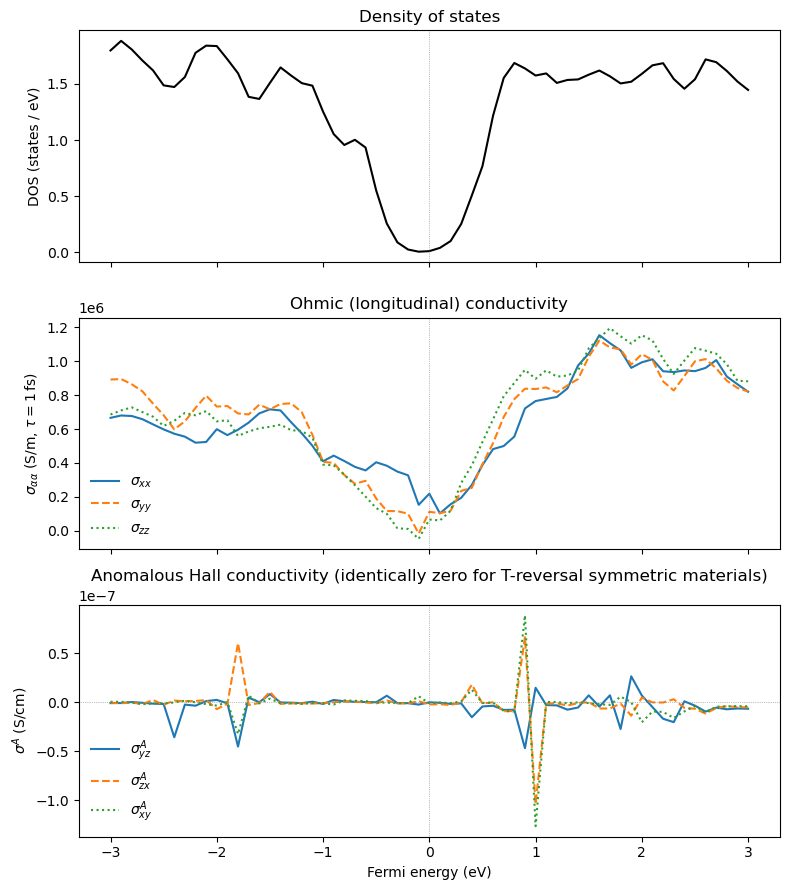

In [11]:
"""Conductivity via WannierBerri on a Tailwater hr-model.

Takes a Tailwater Wannier hr-model (e.g. the API's output),
hands it to ``wannierberri.system.System_R.from_tbmodels`` (no file
I/O — the tbmodels.Model goes in directly), and sweeps three
quantities versus Fermi energy on a uniform Monkhorst-Pack k-mesh:

  1. Density of states              n(E)        [states / eV]
  2. Ohmic conductivity tensor      sigma(E)    [S/m, per 1 fs relax. time]
  3. Anomalous Hall conductivity    sigma^A(E)  [S/cm]  (Berry-curvature integral)

The Ohmic tensor's diagonal (sigma_xx, sigma_yy, sigma_zz) plays the
classic insulating-vs-metallic role: it drops to zero in the bulk gap
and lights up at the band edges.  The AHC is identically zero for a
T-reversal-invariant material (like Bi2Se3) but is included here as a
template — the same calculator handles real Berry-curvature transport
once you point it at a material that breaks T.

Runtime scales as O(num_wann^3 * NK^3).  Defaults below (NK=8,
NKFFT=4) take roughly a minute on a laptop CPU for the 124-orbital model.  Bump NK to 16-20 for production runs.

Requires:
    pip install tailwater
    pip install wannierberri numba                    # numba is needed by
                                                       # tetrahedron integration
"""

import time
import numpy as np
import matplotlib.pyplot as plt
import wannierberri as wb

from tailwater import tb_model


# ----------------------------------------------------------------------
# Sweep parameters
# ----------------------------------------------------------------------
NK_DIV     = 8                                     # k-mesh size per direction
NK_FFT     = 4                                     # FFT mesh size per direction
EFERMI     = np.linspace(-3.0, 3.0, 61)            # Fermi-energy sweep (eV)


def main():
    # ------------------------------------------------------------------
    # 1)  Load the hr-model and hand it to wannierberri
    # ------------------------------------------------------------------
    print("Loading hr-model ...")
    model = tb_model.load("outputs/wannier90_hr.hdf5")

    # `berry=True` builds the position matrix elements <0,n|r|R,m> from
    # the Wannier centres carried by `model.pos`.  These are what the
    # AHC / Berry-curvature calculators need.
    print("Building wannierberri System ...")
    sys_wb = wb.system.System_R.from_tbmodels(model, berry=True)
    print(f"  {sys_wb.num_wann} Wannier functions")

    # ------------------------------------------------------------------
    # 2)  k-grid: uniform mesh, with a smaller inner FFT mesh for speed.
    #     `wb.run` automatically uses the symmetry group attached to the
    #     System (None by default) to reduce the integration to the
    #     irreducible wedge.
    # ------------------------------------------------------------------
    grid = wb.Grid(sys_wb, NK=(NK_DIV,) * 3, NKFFT=(NK_FFT,) * 3)

    # ------------------------------------------------------------------
    # 3)  Calculators
    # ------------------------------------------------------------------
    calculators = {
        "dos":   wb.calculators.static.DOS           (Efermi=EFERMI, tetra=True),
        "ohmic": wb.calculators.static.Ohmic_FermiSea(Efermi=EFERMI),
        "ahc":   wb.calculators.static.AHC           (Efermi=EFERMI),
    }

    # ------------------------------------------------------------------
    # 4)  Run the sweep
    # ------------------------------------------------------------------
    print(f"\nIntegrating on NK={NK_DIV}^3 / NKFFT={NK_FFT}^3 ...")
    t0 = time.time()
    result = wb.run(
        sys_wb,
        grid       = grid,
        calculators= calculators,
        fout_name  = "wb_conductivity",                # writes wb_conductivity-*.dat
        parallel   = False,                            # set True for multi-core
        symmetrize = False,
        print_Kpoints = False,
        dump_results  = False,
    )
    print(f"wb.run finished in {time.time()-t0:.1f} s")

    dos_arr   = np.asarray(result.results["dos"  ].data)        # (Nef,)
    ohmic_arr = np.asarray(result.results["ohmic"].data)        # (Nef, 3, 3)
    ahc_arr   = np.asarray(result.results["ahc"  ].data)        # (Nef, 3)

    # ------------------------------------------------------------------
    # 5)  Save raw results and plot
    # ------------------------------------------------------------------
    np.savez(
        "wb_conductivity.npz",
        efermi = EFERMI,
        dos    = dos_arr,
        ohmic  = ohmic_arr,
        ahc    = ahc_arr,
        NK     = NK_DIV,
        NKFFT  = NK_FFT,
    )

    fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

    # (a) DOS
    axes[0].plot(EFERMI, dos_arr, "k-", lw=1.5)
    axes[0].set_ylabel("DOS (states / eV)")
    axes[0].axvline(0, ls=":", color="gray", lw=0.5)
    axes[0].set_title("Density of states")

    # (b) Ohmic sigma (diagonal of sigma_alpha,beta)
    axes[1].plot(EFERMI, ohmic_arr[:, 0, 0], label=r"$\sigma_{xx}$", lw=1.5)
    axes[1].plot(EFERMI, ohmic_arr[:, 1, 1], label=r"$\sigma_{yy}$", lw=1.5, ls="--")
    axes[1].plot(EFERMI, ohmic_arr[:, 2, 2], label=r"$\sigma_{zz}$", lw=1.5, ls=":")
    axes[1].axvline(0, ls=":", color="gray", lw=0.5)
    axes[1].set_ylabel(r"$\sigma_{\alpha\alpha}$ (S/m, $\tau=1\,$fs)")
    axes[1].set_title("Ohmic (longitudinal) conductivity")
    axes[1].legend(frameon=False)

    # (c) AHC components (sigma^A_x, sigma^A_y, sigma^A_z in the {yz,zx,xy}
    #     channels). Identically zero for time-reversal invariant materials,
    #     so this serves as a sanity check on the integration mesh.
    axes[2].plot(EFERMI, ahc_arr[:, 0], label=r"$\sigma^A_{yz}$", lw=1.5)
    axes[2].plot(EFERMI, ahc_arr[:, 1], label=r"$\sigma^A_{zx}$", lw=1.5, ls="--")
    axes[2].plot(EFERMI, ahc_arr[:, 2], label=r"$\sigma^A_{xy}$", lw=1.5, ls=":")
    axes[2].axvline(0, ls=":", color="gray", lw=0.5)
    axes[2].axhline(0, ls=":", color="gray", lw=0.5)
    axes[2].set_xlabel("Fermi energy (eV)")
    axes[2].set_ylabel(r"$\sigma^A$ (S/cm)")
    axes[2].set_title(
        "Anomalous Hall conductivity "
        "(identically zero for T-reversal symmetric materials)"
    )
    axes[2].legend(frameon=False)

    fig.tight_layout()
    #fig.savefig("wb_conductivity.png", dpi=160)
    #print("\nWrote wb_conductivity.png and wb_conductivity.npz")


if __name__ == "__main__":
    main()

# Since Sb is a TI, we can investigate the SHC using Tailwater's interface to WannierBerri

Reading the system from TBmodels model. Needed data: {'Ham', 'AA'}
[16]
[17]
[23]
[25]
[29]
[31]
[18]
[22]
[32]
[20]
[27]
[19]
[21]
[24]
[26]
[28]
[30]
shape of Ham_R = (33, 36, 36)
Real-space lattice:
 [[3.83577146 0.00594459 2.50485494]
 [1.35894867 3.58698298 2.50485497]
 [0.0085938  0.00594458 4.58119687]]
Number of wannier functions: 36
Number of R points: 33
Recommended size of FFT grid [5 5 5]
Reading the system from TBmodels finished successfully
[tailwater] wb_system_with_spin: attached SS_R for 18 σ_z eigenstate pair(s) out of num_wann=36.
Minimal symmetric FFT grid :  [5 5 5]
Starting run()
Using the follwing calculators : 
############################################################

 'shc'  :  <wannierberri.calculators.static.SHC object at 0x3c7bb6d10>  : Spin Hall conductivity with dc (:math:`S/m`)

        | With Fermi sea integral. Eq(1) in `Ref <https://journals.aps.org/prb/abstract/10.1103/PhysRevB.99.235113>`_
        | Qiao type : with kwargs_formula={'spin_current_

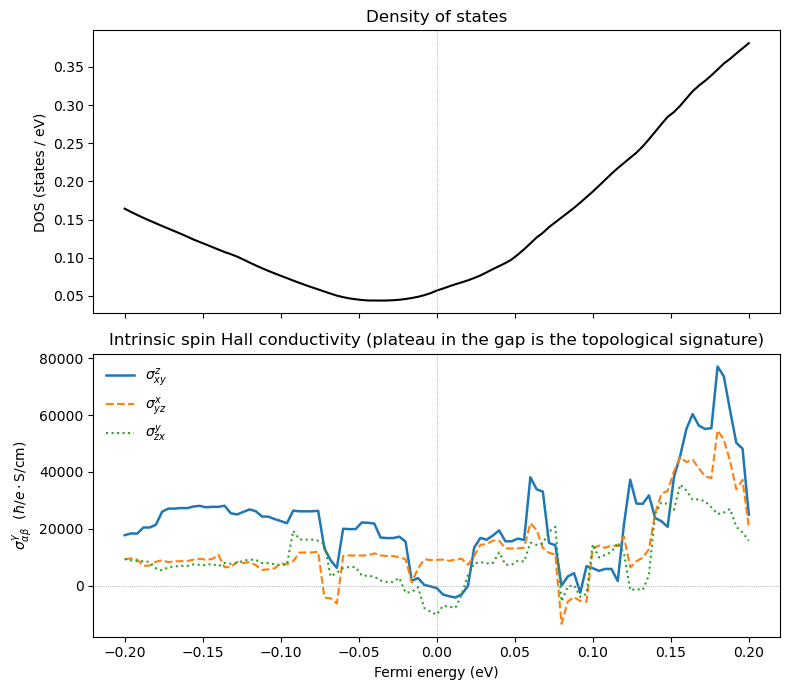

In [16]:
"""Intrinsic spin Hall conductivity via WannierBerri on a Tailwater hr-model.

Strong-SOC insulators are *defined* by a large intrinsic spin Hall conductivity (SHC), so this
calculation is the natural follow-on to example 06's longitudinal
conductivity. Two pieces have to come together:

  * A WannierBerri ``System`` that carries position matrix elements
    (``berry=True``) AND spin matrix elements (``SS_R``). The latter
    is NOT auto-populated when you build a System from a tbmodels
    model — tbmodels stores only the Hamiltonian.

  * The spin matrix elements themselves. For the Tailwater 18-orbital
    basis we know analytically that each Wannier function is a S_z
    eigenstate, so we can build SS_R(R=0) from the (atom, spatial,
    spin) structure of the model — no ab-initio re-projection needed.

``tailwater.wb_system_with_spin(...)`` packages both steps. It infers
the sigma_z eigenstate doublets from the model's atomic-position
topology by default, so a plain call

    sys = wb_system_with_spin(model)

is enough — no basis JSON or hand-built mask needed.

Wall-clock at the defaults below is ~10 s on a laptop CPU for the
124-orbital hr-model. Bump NK_DIV to 16+ for production runs.

Requires:
    pip install tailwater wannierberri numba
"""

import time
import numpy as np
import matplotlib.pyplot as plt
import wannierberri as wb

from tailwater import tb_model, wb_system_with_spin


# ----------------------------------------------------------------------
# Sweep parameters
# ----------------------------------------------------------------------
NK=20
#NK_DIV = 20                                         # k-mesh size per direction
#NK_FFT = 20                                         # FFT mesh size per direction
EFERMI = np.linspace(-0.2, 0.2, 101)                # Fermi-energy sweep (eV)


def main():
    # ------------------------------------------------------------------
    # 1)  Load the hr-model and build a spin-aware WannierBerri System
    # ------------------------------------------------------------------
    #model = tb_model.load("outputs/wannier90_hr.hdf5")

    # Default: infer sigma_z eigenstate pairs from the model's atomic
    # topology (works for compact subspace projections too). If you have
    # a basis.json from `subspace_projection`, pass
    # `basis_json_path="...basis.json"` instead.
    sys_wb = wb_system_with_spin(model)

    # ------------------------------------------------------------------
    # 2)  k-mesh
    # ------------------------------------------------------------------
    #grid = wb.Grid(sys_wb, NK=(NK_DIV,) * 3, NKFFT=(NK_FFT,) * 3)
    grid = wb.Grid(sys_wb, NK=20)

    # ------------------------------------------------------------------
    # 3)  Calculators
    # ------------------------------------------------------------------
    # The 'simple' spin-current type uses only SS_R (which we just set);
    # the 'ryoo'/'qiao' types would additionally need SR_R / SHR_R, which
    # we don't have without an ab-initio re-projection.
    calculators = {
        "shc": wb.calculators.static.SHC(
            Efermi          = EFERMI,
            kwargs_formula  = {"spin_current_type": "simple"},
        ),
        "dos": wb.calculators.static.DOS(Efermi=EFERMI, tetra=True),
    }

    # ------------------------------------------------------------------
    # 4)  Run the sweep
    # ------------------------------------------------------------------
    #print(f"\nIntegrating on NK={NK_DIV}^3 / NKFFT={NK_FFT}^3 ...")
    t0 = time.time()
    result = wb.run(
        sys_wb, grid=grid, calculators=calculators,
        parallel=False, symmetrize=False,
        print_Kpoints=False, dump_results=False,
        fout_name="wb_shc",
    )
    print(f"wb.run finished in {time.time() - t0:.1f} s")

    shc_arr = np.asarray(result.results["shc"].data)      # (Nef, 3, 3, 3) in (ℏ/e)·S/cm
    dos_arr = np.asarray(result.results["dos"].data)      # (Nef,) in states/eV

    # The four canonical SHC components for a hexagonal/trigonal crystal:
    sigma_xy_z = shc_arr[:, 0, 1, 2]                       # σ^z_xy (the "Hall" piece)
    sigma_yz_x = shc_arr[:, 1, 2, 0]
    sigma_zx_y = shc_arr[:, 2, 0, 1]

    # ------------------------------------------------------------------
    # 5)  Save raw results and plot
    # ------------------------------------------------------------------
    np.savez(
        "wb_shc.npz",
        efermi=EFERMI, dos=dos_arr, shc=shc_arr,
        NK=NK_DIV, NKFFT=NK_FFT,
    )

    fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    axes[0].plot(EFERMI, dos_arr, "k-", lw=1.5)
    axes[0].set_ylabel("DOS (states / eV)")
    axes[0].axvline(0, ls=":", color="gray", lw=0.5)
    axes[0].set_title("Density of states")

    axes[1].plot(EFERMI, sigma_xy_z, lw=1.8, label=r"$\sigma^{z}_{xy}$")
    axes[1].plot(EFERMI, sigma_yz_x, lw=1.5, ls="--", label=r"$\sigma^{x}_{yz}$")
    axes[1].plot(EFERMI, sigma_zx_y, lw=1.5, ls=":",  label=r"$\sigma^{y}_{zx}$")
    axes[1].axvline(0, ls=":", color="gray", lw=0.5)
    axes[1].axhline(0, ls=":", color="gray", lw=0.5)
    axes[1].set_xlabel("Fermi energy (eV)")
    axes[1].set_ylabel(r"$\sigma^{\gamma}_{\alpha\beta}$  ($\hbar/e \cdot $S/cm)")
    axes[1].set_title(
        "Intrinsic spin Hall conductivity "
        "(plateau in the gap is the topological signature)"
    )
    axes[1].legend(frameon=False, loc="best")

    fig.tight_layout()
    fig.savefig("wb_shc.png", dpi=160)
    print("\nWrote wb_shc.png and wb_shc.npz")


if __name__ == "__main__":
    main()

Reading the system from TBmodels model. Needed data: {'Ham', 'AA'}
[16]
[17]
[23]
[25]
[29]
[31]
[18]
[22]
[32]
[20]
[27]
[19]
[21]
[24]
[26]
[28]
[30]
shape of Ham_R = (33, 36, 36)
Real-space lattice:
 [[3.83577146 0.00594459 2.50485494]
 [1.35894867 3.58698298 2.50485497]
 [0.0085938  0.00594458 4.58119687]]
Number of wannier functions: 36
Number of R points: 33
Recommended size of FFT grid [5 5 5]
Reading the system from TBmodels finished successfully
Minimal symmetric FFT grid :  [5 5 5]
Starting run()
Using the follwing calculators : 
############################################################

 'dos'  :  <wannierberri.calculators.static.DOS object at 0x3c8cf6d10>  : Density of states
 'cumdos'  :  <wannierberri.calculators.static.CumDOS object at 0x3c8b314d0>  : Cumulative density of states
 'qm'  :  <wannierberri.calculators.static.QuantumMetric_FermiSea object at 0x3c8c89dd0>  : Quantum metric of all occupied states (Angstr^-1)
    
 'nldrude'  :  <wannierberri.calculators.sta

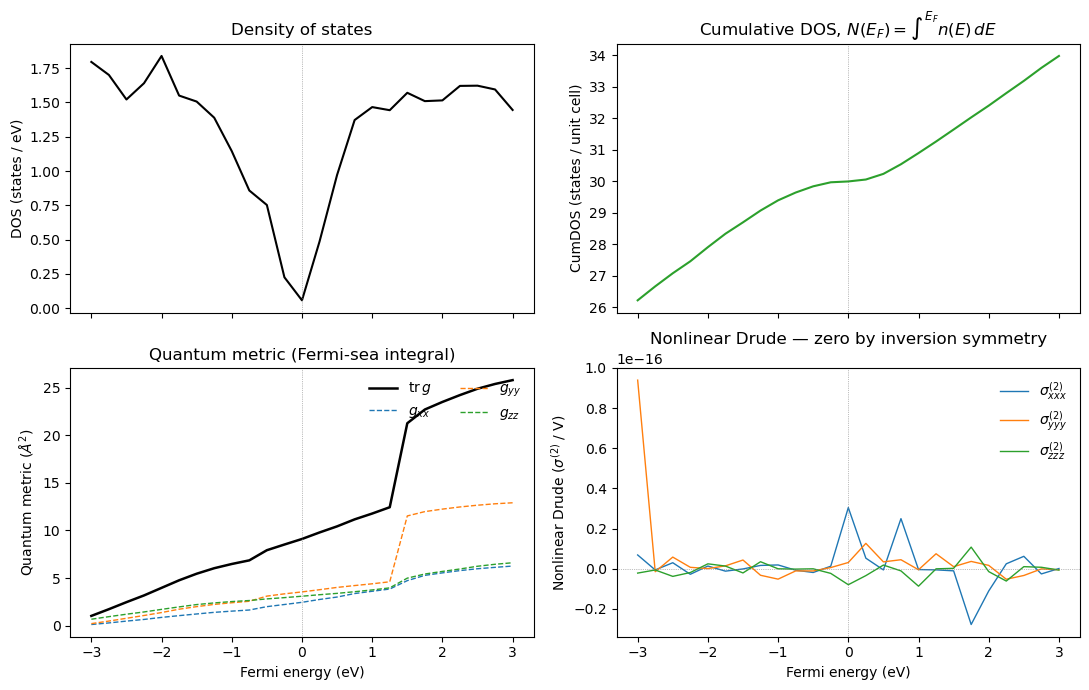

In [19]:
"""Quantum geometry, cumulative DOS, and nonlinear Drude on a Tailwater model.

Three more WannierBerri quantities on top of the longitudinal /
spin-Hall / anomalous-Hall conductivities already covered in
examples 06 and 07, all sharing a single Fermi-energy sweep:

  1. Cumulative DOS                    N(E_F)        [states / unit cell]
     -- integral of n(E) from -inf to E_F.  Use this to convert
        "I want a target carrier density n_e" into the corresponding
        E_F shift in the model.

  2. Quantum metric (Fermi-sea integral)
                                        g_alpha,beta(E_F)  [Angstrom^2]
     -- the symmetric (Re) part of the quantum geometric tensor,
        integrated over occupied bands.  Controls a growing list of
        observables: nonlinear Hall and shift-current cross-sections,
        the bound-state contribution to superfluid stiffness in flat
        bands, the Fubini-Study geometry on the Bloch manifold.
        T-even, so nonzero for Bi2Se3 (unlike AHC).

  3. Nonlinear Drude conductivity      sigma^(2)_xyz(E_F)  [(S/m)/V]
     -- second-order intraband current response.  Vanishes for
        centrosymmetric materials (so identically zero for Bi2Se3),
        but the same calculator gives meaningful answers on
        non-centrosymmetric TRS materials (BiTeI, Te, WTe2, ...).
        Included here as a template + sanity check on the integration
        mesh.

Runtime ~1-2 min at the defaults below; bump NK to 16+ for production.

Requires:
    pip install tailwater wannierberri numba
"""

import time
import numpy as np
import matplotlib.pyplot as plt
import wannierberri as wb

from tailwater import tb_model


#NK_DIV  = 6
#NK_FFT  = 3
EFERMI  = np.linspace(-3.0, 3.0, 25)


def main():
    #model  = tb_model.load("outputs/wannier90_hr.hdf5")
    sys_wb = wb.system.System_R.from_tbmodels(model, berry=True)
    grid   = wb.Grid(sys_wb, NK=20)

    calculators = {
        "dos":     wb.calculators.static.DOS                  (Efermi=EFERMI, tetra=True),
        "cumdos":  wb.calculators.static.CumDOS               (Efermi=EFERMI, tetra=True),
        "qm":      wb.calculators.static.QuantumMetric_FermiSea(Efermi=EFERMI),
        "nldrude": wb.calculators.static.NLDrude_FermiSea     (Efermi=EFERMI),
    }

    #print(f"Integrating on NK={NK_DIV}^3 / NKFFT={NK_FFT}^3 ...")
    t0 = time.time()
    result = wb.run(
        sys_wb, grid=grid, calculators=calculators,
        parallel=False, symmetrize=False,
        print_Kpoints=False, dump_results=False,
        fout_name="wb_geometry",
    )
    print(f"wb.run finished in {time.time() - t0:.1f} s")

    dos    = np.asarray(result.results["dos"    ].data)    # (Nef,)
    cumdos = np.asarray(result.results["cumdos" ].data)    # (Nef,)
    qm     = np.asarray(result.results["qm"     ].data)    # (Nef, 3, 3) — symmetric
    nld    = np.asarray(result.results["nldrude"].data)    # (Nef, 3, 3, 3)

    np.savez(
        "wb_geometry.npz",
        efermi=EFERMI, dos=dos, cumdos=cumdos, qm=qm, nldrude=nld,
        NK=NK_DIV, NKFFT=NK_FFT,
    )

    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

    # (a) DOS — same panel as 06, included for context.
    axes[0, 0].plot(EFERMI, dos, "k-", lw=1.5)
    axes[0, 0].axvline(0, ls=":", color="gray", lw=0.5)
    axes[0, 0].set_ylabel("DOS (states / eV)")
    axes[0, 0].set_title("Density of states")

    # (b) Cumulative DOS — read this to set E_F for a given carrier
    #     count.  At E_F=0 the value tells you how many states sit
    #     below the bulk gap.
    axes[0, 1].plot(EFERMI, cumdos, "C2-", lw=1.5)
    axes[0, 1].axvline(0, ls=":", color="gray", lw=0.5)
    axes[0, 1].set_ylabel("CumDOS (states / unit cell)")
    axes[0, 1].set_title(r"Cumulative DOS, $N(E_F) = \int^{E_F} n(E)\,dE$")

    # (c) Quantum metric — trace and the three Cartesian diagonals.
    qm_trace = qm[:, 0, 0] + qm[:, 1, 1] + qm[:, 2, 2]
    axes[1, 0].plot(EFERMI, qm_trace, "k-", lw=1.8, label=r"$\mathrm{tr}\,g$")
    axes[1, 0].plot(EFERMI, qm[:, 0, 0], "C0--", lw=1.0, label=r"$g_{xx}$")
    axes[1, 0].plot(EFERMI, qm[:, 1, 1], "C1--", lw=1.0, label=r"$g_{yy}$")
    axes[1, 0].plot(EFERMI, qm[:, 2, 2], "C2--", lw=1.0, label=r"$g_{zz}$")
    axes[1, 0].axvline(0, ls=":", color="gray", lw=0.5)
    axes[1, 0].set_xlabel("Fermi energy (eV)")
    axes[1, 0].set_ylabel(r"Quantum metric ($\AA^2$)")
    axes[1, 0].set_title("Quantum metric (Fermi-sea integral)")
    axes[1, 0].legend(frameon=False, loc="upper right", ncol=2)

    # (d) Nonlinear Drude — three representative diagonal channels.
    #     Magnitudes around ~1e-18 below indicate the centrosymmetric
    #     zero of Bi2Se3; on a non-centrosymmetric TRS material you'd
    #     see structure of order 1 (Angstrom^2 / V) inside the bands.
    axes[1, 1].plot(EFERMI, nld[:, 0, 0, 0], lw=1.0, label=r"$\sigma^{(2)}_{xxx}$")
    axes[1, 1].plot(EFERMI, nld[:, 1, 1, 1], lw=1.0, label=r"$\sigma^{(2)}_{yyy}$")
    axes[1, 1].plot(EFERMI, nld[:, 2, 2, 2], lw=1.0, label=r"$\sigma^{(2)}_{zzz}$")
    axes[1, 1].axvline(0, ls=":", color="gray", lw=0.5)
    axes[1, 1].axhline(0, ls=":", color="gray", lw=0.5)
    axes[1, 1].set_xlabel("Fermi energy (eV)")
    axes[1, 1].set_ylabel(r"Nonlinear Drude ($\sigma^{(2)}$ / V)")
    axes[1, 1].set_title(
        "Nonlinear Drude — zero by inversion symmetry"
    )
    axes[1, 1].legend(frameon=False, loc="best")

    fig.tight_layout()
    fig.savefig("wb_geometry.png", dpi=160)
    print("\nWrote wb_geometry.png and wb_geometry.npz")


if __name__ == "__main__":
    main()

Reading the system from TBmodels model. Needed data: {'Ham', 'AA'}
[16]
[17]
[23]
[25]
[29]
[31]
[18]
[22]
[32]
[20]
[27]
[19]
[21]
[24]
[26]
[28]
[30]
shape of Ham_R = (33, 36, 36)
Real-space lattice:
 [[3.83577146 0.00594459 2.50485494]
 [1.35894867 3.58698298 2.50485497]
 [0.0085938  0.00594458 4.58119687]]
Number of wannier functions: 36
Number of R points: 33
Recommended size of FFT grid [5 5 5]
Reading the system from TBmodels finished successfully
Minimal symmetric FFT grid :  [5 5 5]
Starting run()
Using the follwing calculators : 
############################################################

 'optical'  :  <wannierberri.calculators.dynamic.OpticalConductivity object at 0x3cb199190>  : calculator not described
############################################################
Calculation on  grid - checking calculators for compatibility
optical <wannierberri.calculators.dynamic.OpticalConductivity object at 0x3cb199190>
All calculators are compatible
Grid is regular
The set of k poin

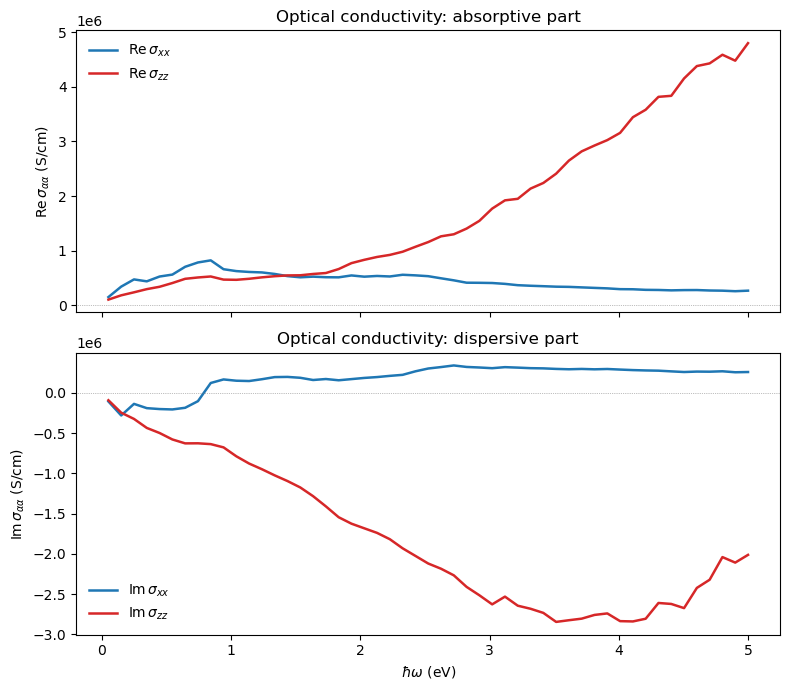

In [18]:
"""Optical conductivity sigma(omega) on a Tailwater hr-model.

The interband Kubo formula yields the complex optical conductivity
tensor sigma_alpha,beta(omega) at a fixed chemical potential.  Real
part is dissipative (the canonical "absorption spectrum"); imaginary
part is dispersive.  T-even, so meaningful for Bi2Se3.

For a hexagonal/trigonal crystal like Bi2Se3 the tensor has two
independent diagonal channels:

    sigma_xx = sigma_yy  (in-plane)
    sigma_zz             (out-of-plane, along the c-axis)

This script sweeps both versus omega for a single E_F (= 0, the
Tailwater Fermi reference) and plots Re sigma + Im sigma.

Wall-clock at the defaults below (NK=8^3, 51 omega points) is
~3-5 min on a laptop CPU; bump NK to 14-16 for production. The
dynamic calculator does (Nomega * 3 * 3) work per k, so omega-grid
density is the main cost knob.

Requires:
    pip install tailwater wannierberri numba
"""

import time
import numpy as np
import matplotlib.pyplot as plt
import wannierberri as wb

from tailwater import tb_model


NK_DIV = 8
NK_FFT = 4
OMEGA  = np.linspace(0.05, 5.0, 51)       # photon energy (eV); skip omega=0 (Drude pole)
EFERMI = np.array([0.0])                  # single chemical potential
SMR    = 0.05                             # Lorentzian smearing (eV) -- broadens delta peaks


def main():
    model  = tb_model.load("outputs/wannier90_hr.hdf5")
    sys_wb = wb.system.System_R.from_tbmodels(model, berry=True)
    grid   = wb.Grid(sys_wb, NK=20)

    calculators = {
        "optical": wb.calculators.dynamic.OpticalConductivity(
            Efermi          = EFERMI,
            omega           = OMEGA,
            smr_fixed_width = SMR,
            smr_type        = "Lorentzian",
        ),
    }

    #print(f"Integrating on NK={NK_DIV}^3 / NKFFT={NK_FFT}^3, {len(OMEGA)} omega points ...")
    t0 = time.time()
    result = wb.run(
        sys_wb, grid=grid, calculators=calculators,
        parallel=False, symmetrize=False,
        print_Kpoints=False, dump_results=False,
        fout_name="wb_optical",
    )
    print(f"wb.run finished in {time.time() - t0:.1f} s")

    # (1, Nomega, 3, 3) -> (Nomega, 3, 3)
    sigma = np.asarray(result.results["optical"].data)[0]

    np.savez(
        "wb_optical.npz",
        omega=OMEGA, efermi=EFERMI, sigma=sigma,
        NK=NK_DIV, NKFFT=NK_FFT, smr_width=SMR,
    )

    fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    # (a) Real part of sigma -- absorption.  sigma_xx vs sigma_zz exposes
    #     the trigonal anisotropy (in-plane vs out-of-plane).
    axes[0].plot(OMEGA, sigma[:, 0, 0].real, "C0-", lw=1.8, label=r"$\mathrm{Re}\,\sigma_{xx}$")
    axes[0].plot(OMEGA, sigma[:, 2, 2].real, "C3-", lw=1.8, label=r"$\mathrm{Re}\,\sigma_{zz}$")
    axes[0].axhline(0, ls=":", color="gray", lw=0.5)
    axes[0].set_ylabel(r"$\mathrm{Re}\,\sigma_{\alpha\alpha}$ (S/cm)")
    axes[0].set_title(r"Optical conductivity: absorptive part")
    axes[0].legend(frameon=False, loc="best")

    # (b) Imaginary part -- dispersive.  Kramers-Kronig partner of (a).
    axes[1].plot(OMEGA, sigma[:, 0, 0].imag, "C0-", lw=1.8, label=r"$\mathrm{Im}\,\sigma_{xx}$")
    axes[1].plot(OMEGA, sigma[:, 2, 2].imag, "C3-", lw=1.8, label=r"$\mathrm{Im}\,\sigma_{zz}$")
    axes[1].axhline(0, ls=":", color="gray", lw=0.5)
    axes[1].set_xlabel(r"$\hbar\omega$ (eV)")
    axes[1].set_ylabel(r"$\mathrm{Im}\,\sigma_{\alpha\alpha}$ (S/cm)")
    axes[1].set_title(r"Optical conductivity: dispersive part")
    axes[1].legend(frameon=False, loc="best")

    fig.tight_layout()
    fig.savefig("wb_optical.png", dpi=160)
    print("\nWrote wb_optical.png and wb_optical.npz")


if __name__ == "__main__":
    main()